# SA vs NSW — Match Review
**Sheffield Shield 2024/25 | Match ID: 1444492**  
**Venue:** Cricket Central, Sydney | **Dates:** 8–11 October 2024

---

This notebook provides a ball-by-ball analysis of the SA vs NSW Sheffield Shield match. It covers:

1. [Data Loading & Feature Engineering](#1-data-loading)
2. [Match Summary](#2-match-summary)
3. [Phase Analysis — Run Rate & Dot Balls](#3-phase-analysis)
4. [Bowling Spell Analysis](#4-bowling-spells)
5. [Batter Impact Scores](#5-batter-impact)
6. [Key Player Deep Dives](#6-player-deep-dives)
7. [Carey & McSweeney 4th Innings Partnership](#7-partnership-progression)

## 1. Data Loading & Feature Engineering

Load the combined SA dataset, filter to this match, and derive key engineered features:
- `is_dot` — ball produced zero runs
- `is_boundary` — batter scored 4 or 6
- `wickets_last_15` — rolling wicket count over last 15 balls (collapse detector)
- `partnership_id` — increments on each wicket, used to group partnership stands
- `phase` — over block: 1–20, 21–50, 51+

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Config ────────────────────────────────────────────────────────────────────
MATCH_ID   = 1444492
DATA_PATH  = "../data/processed/sa_combined.csv"
TEAM_SA    = "South Australia"
TEAM_NSW   = "New South Wales"

TEAM_COLORS = {
    TEAM_NSW: "#1B3A5C",
    TEAM_SA:  "#7B0D1E"
}

# ── Load & filter ─────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH, low_memory=False)
match_df = df[df["match_id"] == MATCH_ID].copy()

# Sort chronologically
match_df = match_df.sort_values(["innings", "over", "ball_in_over"]).reset_index(drop=True)

# ── Feature engineering ───────────────────────────────────────────────────────
match_df["is_dot"]      = (match_df["runs_total"] == 0).astype(int)
match_df["is_boundary"] = match_df["runs_batter"].isin([4, 6]).astype(int)

# Rolling wicket count (collapse window = 2+ wickets in last 15 balls)
match_df["wickets_last_15"] = (
    match_df.groupby("innings")["is_wicket"]
    .rolling(window=15, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)
match_df["collapse_window"] = match_df["wickets_last_15"] >= 2

# Partnership ID — increments with each wicket within an innings
match_df["partnership_id"] = match_df.groupby("innings")["is_wicket"].cumsum()

# Bowling team (derived from batting team)
match_df["bowling_team"] = np.where(
    match_df["batting_team"] == TEAM_NSW, TEAM_SA, TEAM_NSW
)

# Over phase
def assign_phase(over):
    if over <= 20:   return "1-20"
    elif over <= 50: return "21-50"
    else:            return "51+"

match_df["phase"] = match_df["over"].apply(assign_phase)

print(f"Match loaded: {len(match_df):,} deliveries across {match_df['innings'].nunique()} innings")
match_df.head(1)

Match loaded: 2,264 deliveries across 4 innings


,match_id,season,event,match_number,start_date,dates,venue,city,team_1,team_2,...,dismissal_type,wicket_bowler,fielder_1,fielder_2,is_dot,is_boundary,wickets_last_15,collapse_window,partnership_id,phase
0,1444492,2024/25,Sheffield Shield,1.0,2024-10-08,"2024-10-08, 2024-10-09, 2024-10-10, 2024-10-11","Cricket Central, Sydney",Sydney,New South Wales,South Australia,...,NaN,NaN,NaN,NaN,0,0,0.0,False,0,1-20


## 2. Match Summary

High-level innings breakdown — runs, wickets and balls for each innings.

In [2]:
innings_summary = (
    match_df.groupby(["innings", "batting_team"])
    .agg(
        runs    = ("runs_total",   "sum"),
        wickets = ("is_wicket",    "sum"),
        balls   = ("ball_in_over", "count")
    )
)
innings_summary["overs"] = (innings_summary["balls"] / 6).round(1)
innings_summary

,,runs,wickets,balls,overs
innings,batting_team,,,,
1,New South Wales,366,10,603,100.5
2,South Australia,260,10,522,87.0
3,New South Wales,282,6,475,79.2
4,South Australia,309,5,664,110.7


Top 10 individual batting performances across all innings.

In [3]:
(
    match_df.groupby(["innings", "batting_team", "batter"])
    .agg(runs=("runs_batter", "sum"), balls=("ball_in_over", "count"))
    .assign(strike_rate=lambda x: (x["runs"] / x["balls"] * 100).round(1))
    .sort_values("runs", ascending=False)
    .head(10)
)

runs  balls  strike_rate
innings batting_team    batter                                
1       New South Wales S Konstas      152    241         63.1
4       South Australia NA McSweeney   127    283         44.9
                        AT Carey       111    158         70.3
3       New South Wales S Konstas      105    226         46.5
2       South Australia AT Carey        90     85        105.9
1       New South Wales JR Philippe     56     93         60.2
2       South Australia NA McSweeney    55    164         33.5
3       New South Wales MC Henriques    52     83         62.7
4       South Australia DR Drew         46    141         32.6
1       New South Wales O Davies        37     44         84.1

## 3. Phase Analysis — Run Rate & Dot Balls

Breaks each innings into three phases (overs 1–20, 21–50, 51+) and computes run rate and dot ball percentage. This reveals how each team's scoring pattern evolved through the match.

In [4]:
phase_summary = (
    match_df
    .groupby(["innings", "batting_team", "phase"])
    .agg(
        runs     = ("runs_total",   "sum"),
        balls    = ("ball_in_over", "count"),
        wickets  = ("is_wicket",    "sum"),
        dots     = ("runs_total",   lambda x: (x == 0).sum())
    )
    .reset_index()
)
phase_summary["run_rate"] = phase_summary["runs"] / (phase_summary["balls"] / 6)
phase_summary["dot_pct"]  = phase_summary["dots"] / phase_summary["balls"]

phase_summary.sort_values(["innings", "phase"])

,innings,batting_team,phase,runs,balls,wickets,dots,run_rate,dot_pct
0,1,New South Wales,1-20,65,128,1,96,3.046875,0.750000
1,1,New South Wales,21-50,112,182,3,129,3.692308,0.708791
2,1,New South Wales,51+,189,293,6,192,3.870307,0.655290
3,2,South Australia,1-20,50,129,1,105,2.325581,0.813953
4,2,South Australia,21-50,103,180,2,136,3.433333,0.755556
5,2,South Australia,51+,107,213,7,151,3.014085,0.708920
6,3,New South Wales,1-20,59,128,2,101,2.765625,0.789062
7,3,New South Wales,21-50,103,180,1,121,3.433333,0.672222
8,3,New South Wales,51+,120,167,3,95,4.311377,0.568862
9,4,South Australia,1-20,36,126,4,107,1.714286,0.849206


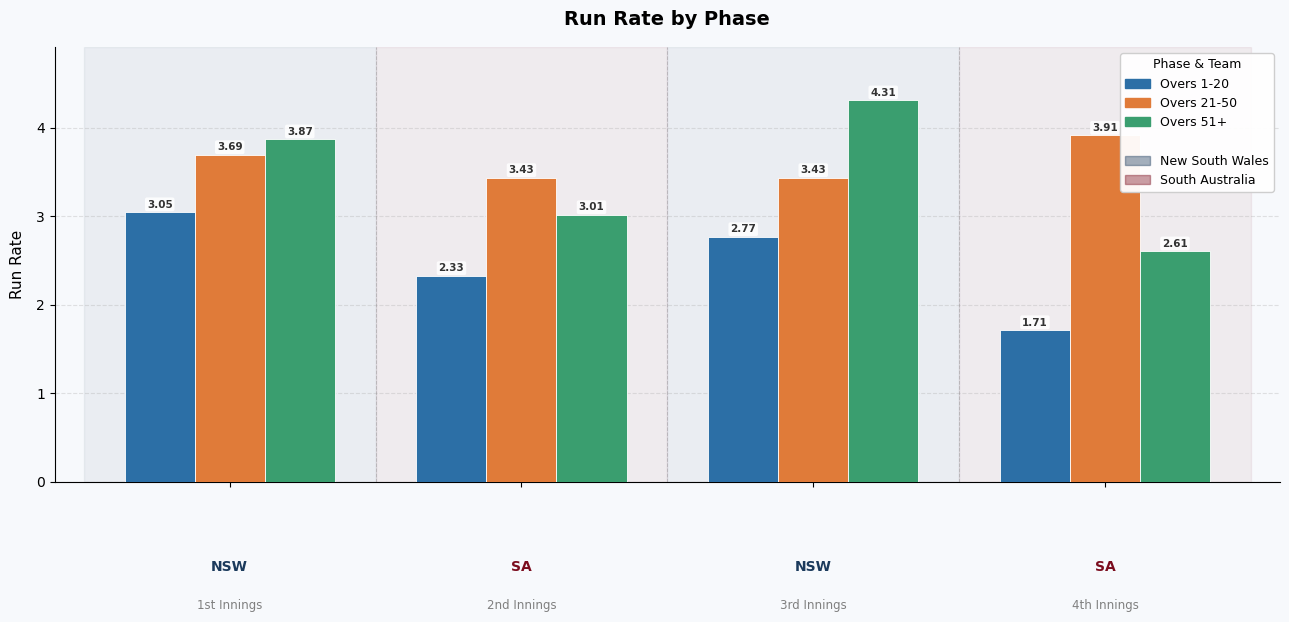

In [5]:
phase_order = ["1-20", "21-50", "51+"]
phase_colors = {"1-20": "#2C6FA6", "21-50": "#E07B39", "51+": "#3A9E6F"}

phase_plot = phase_summary.copy()
phase_plot["phase"] = pd.Categorical(phase_plot["phase"], categories=phase_order, ordered=True)

pivot = (
    phase_plot
    .pivot(index=["innings", "batting_team"], columns="phase", values="run_rate")
    .reindex(columns=phase_order)
)

n, width, offsets = len(pivot), 0.24, [-1, 0, 1]
x = np.arange(n)

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor("#F7F9FC")
ax.set_facecolor("#F7F9FC")

# Alternating innings background
for j in range(n):
    ax.axvspan(j - 0.5, j + 0.5, color=TEAM_COLORS[pivot.index[j][1]], alpha=0.06, zorder=0)

# Bars
for i, phase in enumerate(phase_order):
    vals   = pivot[phase].values
    offset = offsets[i] * width
    ax.bar(x + offset, vals, width=width, color=phase_colors[phase],
           label=phase, zorder=3, edgecolor="white", linewidth=0.6)
    for j, v in enumerate(vals):
        if not np.isnan(v):
            ax.text(x[j] + offset, v + 0.03, f'{v:.2f}',
                    ha='center', va='bottom', fontsize=7.5, fontweight='bold',
                    color='#333333',
                    bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor='none', alpha=0.85))

# Innings dividers
for j in range(n - 1):
    ax.axvline(j + 0.5, color='grey', linewidth=0.7, linestyle='--', alpha=0.35, zorder=1)

# X-axis labels
ax.set_xticks(x)
ax.set_xticklabels([])
for j, (inn, team) in enumerate(pivot.index):
    team_short = "NSW" if TEAM_NSW in team else "SA"
    suffix     = ["1st", "2nd", "3rd", "4th"][inn - 1]
    ax.text(j, -0.18, team_short, transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=10, fontweight='bold', color=TEAM_COLORS[team])
    ax.text(j, -0.27, f'{suffix} Innings', transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=8.5, color='grey')

ax.set_ylabel("Run Rate", fontsize=11, labelpad=8)
ax.set_title("Run Rate by Phase", fontsize=14, fontweight="bold", pad=16)
ax.set_xlim(-0.6, n - 0.4)
ax.set_ylim(0, pivot.values.max() + 0.6)
ax.grid(axis='y', linestyle='--', alpha=0.35, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

phase_patches = [mpatches.Patch(color=phase_colors[p], label=f'Overs {p}') for p in phase_order]
team_patches  = [mpatches.Patch(color=TEAM_COLORS[t], alpha=0.4, label=t) for t in [TEAM_NSW, TEAM_SA]]
ax.legend(handles=phase_patches + [mpatches.Patch(visible=False)] + team_patches,
          fontsize=9, loc='upper right', framealpha=0.95, title="Phase & Team", title_fontsize=9)

plt.tight_layout()
plt.savefig("run_rate_by_phase.png", dpi=150, bbox_inches='tight')
plt.show()

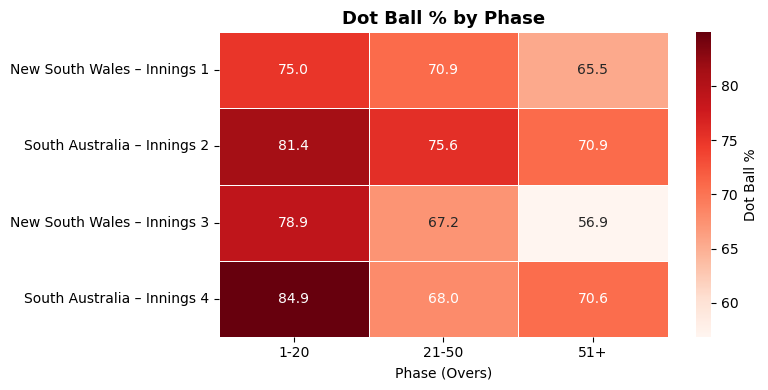

In [6]:
# Dot ball % heatmap by innings and phase
phase_dot = phase_summary.copy()
phase_dot["label"] = phase_dot["batting_team"] + " – Innings " + phase_dot["innings"].astype(str)

label_order = [
    f"{phase_dot[phase_dot['innings'] == inn].iloc[0]['batting_team']} – Innings {inn}"
    for inn in sorted(phase_dot["innings"].unique())
]

heatmap_data = (
    phase_dot.pivot(index="label", columns="phase", values="dot_pct")
    .reindex(label_order)
    .reindex(columns=["1-20", "21-50", "51+"])
) * 100  # convert to percentage

plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="Reds",
            linewidths=0.5, cbar_kws={"label": "Dot Ball %"})
plt.title("Dot Ball % by Phase", fontsize=13, fontweight='bold')
plt.xlabel("Phase (Overs)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("dot_ball_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Bowling Spell Analysis

Identifies distinct bowling spells (a new spell begins if a bowler is away for more than 2 overs) and ranks them by an impact score:

```
impact_score = (wickets × 2) - economy + (dot_pct × 2)
```

Only spells of 4+ overs are included to filter out token overs.

In [7]:
# Summarise each over by bowler
over_bowler = (
    match_df
    .groupby(["innings", "bowler", "over"])
    .agg(
        runs    = ("runs_total",   "sum"),
        wickets = ("is_wicket",    "sum"),
        balls   = ("ball_in_over", "count"),
        dots    = ("runs_total",   lambda x: (x == 0).sum())
    )
    .reset_index()
)
over_bowler["dot_pct"] = over_bowler["dots"] / over_bowler["balls"]
over_bowler = over_bowler.sort_values(["innings", "bowler", "over"])

# Detect spell breaks (gap > 2 overs = new spell)
over_bowler["prev_over"] = over_bowler.groupby(["innings", "bowler"])["over"].shift(1)
over_bowler["new_spell"] = (
    over_bowler["prev_over"].isna() |
    (over_bowler["over"] - over_bowler["prev_over"] > 2)
)
over_bowler["spell_id"] = over_bowler.groupby(["innings", "bowler"])["new_spell"].cumsum()

# Aggregate to spell level
spell_summary = (
    over_bowler
    .groupby(["innings", "bowler", "spell_id"])
    .agg(
        start_over = ("over",    "min"),
        end_over   = ("over",    "max"),
        overs      = ("over",    "nunique"),
        runs       = ("runs",    "sum"),
        wickets    = ("wickets", "sum"),
        balls      = ("balls",   "sum"),
        dot_pct    = ("dot_pct", "mean")
    )
    .reset_index()
)

spell_summary["economy"]      = spell_summary["runs"] / spell_summary["overs"]
spell_summary["impact_score"] = (
    spell_summary["wickets"] * 2
    - spell_summary["economy"]
    + spell_summary["dot_pct"] * 2
)
spell_summary["batting_team"] = spell_summary["innings"].map(
    match_df.groupby("innings")["batting_team"].first()
)

# Top 10 most impactful spells (min 4 overs)
spell_summary[spell_summary["overs"] >= 4].sort_values("impact_score", ascending=False).head(10)

,innings,bowler,spell_id,start_over,end_over,overs,runs,wickets,balls,dot_pct,economy,impact_score,batting_team
37,2,NM Lyon,3,58,78,11,23,3,66,0.727273,2.090909,5.363636,South Australia
70,4,NM Lyon,1,1,23,12,31,3,72,0.805556,2.583333,5.027778,South Australia
24,1,N McAndrew,6,83,93,6,10,2,36,0.833333,1.666667,4.000000,New South Wales
62,4,J Nisbet,1,8,18,6,6,1,36,0.833333,1.000000,2.666667,South Australia
49,3,JS Buckingham,3,59,69,6,19,2,39,0.653770,3.166667,2.140873,New South Wales
17,1,L Pope,4,72,80,5,27,3,30,0.600000,5.400000,1.800000,New South Wales
39,2,T Sangha,1,23,39,9,33,2,54,0.703704,3.666667,1.740741,South Australia
10,1,JS Buckingham,2,18,30,7,16,1,43,0.816327,2.285714,1.346939,New South Wales
11,1,JS Buckingham,3,41,47,4,10,1,25,0.797619,2.500000,1.095238,New South Wales
32,2,LC Hatcher,1,8,24,9,23,1,55,0.780423,2.555556,1.005291,South Australia


### NM Lyon Deep Dive

Lyon was the key bowler in this match. The cells below break down his two key spells:
- **Innings 2:** Overs 58–78 (SA's first innings)
- **Innings 4:** Overs 1–23 (SA's chase)

For each spell, we show how SA batters fared against him ball-by-ball.

In [8]:
def bowler_matchup(df, innings, bowler, over_start, over_end):
    """Batter-level breakdown for a specific bowler spell."""
    spell_df = df[
        (df["innings"] == innings) &
        (df["bowler"] == bowler) &
        (df["over"].between(over_start, over_end))
    ].copy()

    result = (
        spell_df.groupby("batter")
        .agg(
            balls      = ("ball_in_over", "count"),
            runs       = ("runs_total",   "sum"),
            dots       = ("runs_total",   lambda x: (x == 0).sum()),
            boundaries = ("runs_total",   lambda x: ((x == 4) | (x == 6)).sum()),
            singles    = ("runs_total",   lambda x: (x == 1).sum()),
            doubles    = ("runs_total",   lambda x: (x == 2).sum()),
            wickets    = ("is_wicket",    "sum")
        )
        .reset_index()
    )
    result["dot_pct"]      = (result["dots"]       / result["balls"] * 100).round(1)
    result["boundary_pct"] = (result["boundaries"] / result["balls"] * 100).round(1)
    return result.sort_values("balls", ascending=False)

print("NM Lyon — Innings 2 (Overs 58–78)")
bowler_matchup(match_df, innings=2, bowler="NM Lyon", over_start=58, over_end=78)

NM Lyon — Innings 2 (Overs 58–78)


,batter,balls,runs,dots,boundaries,singles,doubles,wickets,dot_pct,boundary_pct
5,NA McSweeney,22,9,15,0,6,0,0,68.2,0.0
1,B Doggett,17,5,15,1,1,0,0,88.2,5.9
0,AT Carey,11,7,4,0,7,0,1,36.4,0.0
4,N McAndrew,9,2,7,0,2,0,0,77.8,0.0
2,BAD Manenti,4,0,4,0,0,0,1,100.0,0.0
3,DR Drew,3,0,3,0,0,0,1,100.0,0.0


In [9]:
print("NM Lyon — Innings 4 (Overs 1–23)")
bowler_matchup(match_df, innings=4, bowler="NM Lyon", over_start=1, over_end=23)

NM Lyon — Innings 4 (Overs 1–23)


,batter,balls,runs,dots,boundaries,singles,doubles,wickets,dot_pct,boundary_pct
3,N McAndrew,18,2,17,0,0,1,1,94.4,0.0
4,NA McSweeney,17,11,12,1,2,1,0,70.6,5.9
5,TM Head,12,9,9,2,1,0,1,75.0,16.7
0,AT Carey,10,7,7,1,1,1,0,70.0,10.0
1,CJ McInerney,9,0,9,0,0,0,1,100.0,0.0
2,HJ Hunt,6,2,4,0,2,0,0,66.7,0.0


## 5. Batter Impact Scores

A composite impact score for each batter, weighted across four dimensions:

| Dimension | Weight | What it captures |
|---|---|---|
| Team run % | 40% | Share of team's total runs |
| Runs in collapse | 30% | Runs scored when wickets were falling |
| Dot ball rate (inverted) | 20% | Ability to rotate strike |
| Max partnership | 10% | Biggest stand contribution |

In [10]:
# Base batting stats
bat_impact = (
    match_df
    .groupby(["innings", "batting_team", "batter"])
    .agg(
        runs       = ("runs_batter", "sum"),
        balls      = ("ball_in_over", "count"),
        dots       = ("is_dot",       "sum"),
        boundaries = ("is_boundary",  "sum")
    )
    .reset_index()
)
bat_impact["strike_rate"] = (bat_impact["runs"] / bat_impact["balls"] * 100).round(1)
bat_impact["dot_pct"]     = bat_impact["dots"] / bat_impact["balls"]

# Team run %
team_totals = (
    match_df.groupby(["innings", "batting_team"])
    .agg(team_runs=("runs_batter", "sum"))
    .reset_index()
)
bat_impact = bat_impact.merge(team_totals, on=["innings", "batting_team"], how="left")
bat_impact["team_run_pct"] = bat_impact["runs"] / bat_impact["team_runs"]

# Runs in collapse
collapse_runs = (
    match_df[match_df["collapse_window"]]
    .groupby(["innings", "batter"])
    .agg(runs_in_collapse=("runs_batter", "sum"))
    .reset_index()
)
bat_impact = bat_impact.merge(collapse_runs, on=["innings", "batter"], how="left")
bat_impact["runs_in_collapse"] = bat_impact["runs_in_collapse"].fillna(0)

# Max partnership
partnership_runs = (
    match_df
    .groupby(["innings", "partnership_id", "batter"])
    .agg(partnership_runs=("runs_batter", "sum"))
    .reset_index()
)
max_partnership = (
    partnership_runs
    .groupby(["innings", "batter"])
    .agg(max_partnership_runs=("partnership_runs", "max"))
    .reset_index()
)
bat_impact = bat_impact.merge(max_partnership, on=["innings", "batter"], how="left")

# Normalise & compute composite score
bat_impact["norm_team_pct"]    = bat_impact["team_run_pct"]        / bat_impact["team_run_pct"].max()
bat_impact["norm_collapse"]    = bat_impact["runs_in_collapse"]     / (bat_impact["runs_in_collapse"].max() + 1)
bat_impact["norm_dot"]         = 1 - bat_impact["dot_pct"]
bat_impact["norm_partnership"] = bat_impact["max_partnership_runs"] / (bat_impact["max_partnership_runs"].max() + 1)

bat_impact["impact_score"] = (
    0.4 * bat_impact["norm_team_pct"]
    + 0.3 * bat_impact["norm_collapse"]
    + 0.2 * bat_impact["norm_dot"]
    + 0.1 * bat_impact["norm_partnership"]
)

# Display top 10
bat_impact[
    ["innings", "batting_team", "batter", "runs", "balls", "strike_rate",
     "dot_pct", "team_run_pct", "runs_in_collapse", "max_partnership_runs", "impact_score"]
].sort_values("impact_score", ascending=False).head(10)

,innings,batting_team,batter,runs,balls,strike_rate,dot_pct,team_run_pct,runs_in_collapse,max_partnership_runs,impact_score
35,4,South Australia,NA McSweeney,127,283,44.9,0.692580,0.419142,1.0,69,0.651422
28,3,New South Wales,S Konstas,105,226,46.5,0.721239,0.384615,1.0,41,0.589525
9,1,New South Wales,S Konstas,152,241,63.1,0.672199,0.443149,0.0,79,0.536096
30,4,South Australia,AT Carey,111,158,70.3,0.639241,0.366337,0.0,111,0.501926
11,2,South Australia,AT Carey,90,85,105.9,0.552941,0.357143,0.0,90,0.492137
20,2,South Australia,NA McSweeney,55,164,33.5,0.780488,0.218254,1.0,41,0.427513
25,3,New South Wales,MC Henriques,52,83,62.7,0.638554,0.190476,0.0,52,0.290648
2,1,New South Wales,JR Philippe,56,93,60.2,0.602151,0.163265,0.0,56,0.276938
22,3,New South Wales,J Edwards,36,45,80.0,0.444444,0.131868,0.0,23,0.250675
27,3,New South Wales,O Davies,36,39,92.3,0.512821,0.131868,0.0,36,0.248607


## 6. Key Player Deep Dives

### Sam Konstas — Batter vs Bowler Profile

Konstas scored 152 (1st innings) and 105 (3rd innings). The bubble chart below shows:
- **X axis:** Balls faced against each bowler
- **Y axis:** Runs scored
- **Bubble size:** Boundary runs
- **Bubble colour:** Dot ball % (green = low, red = high)
- **Diagonal lines:** Strike rate reference lines (SR 25, 50, 75, 100)

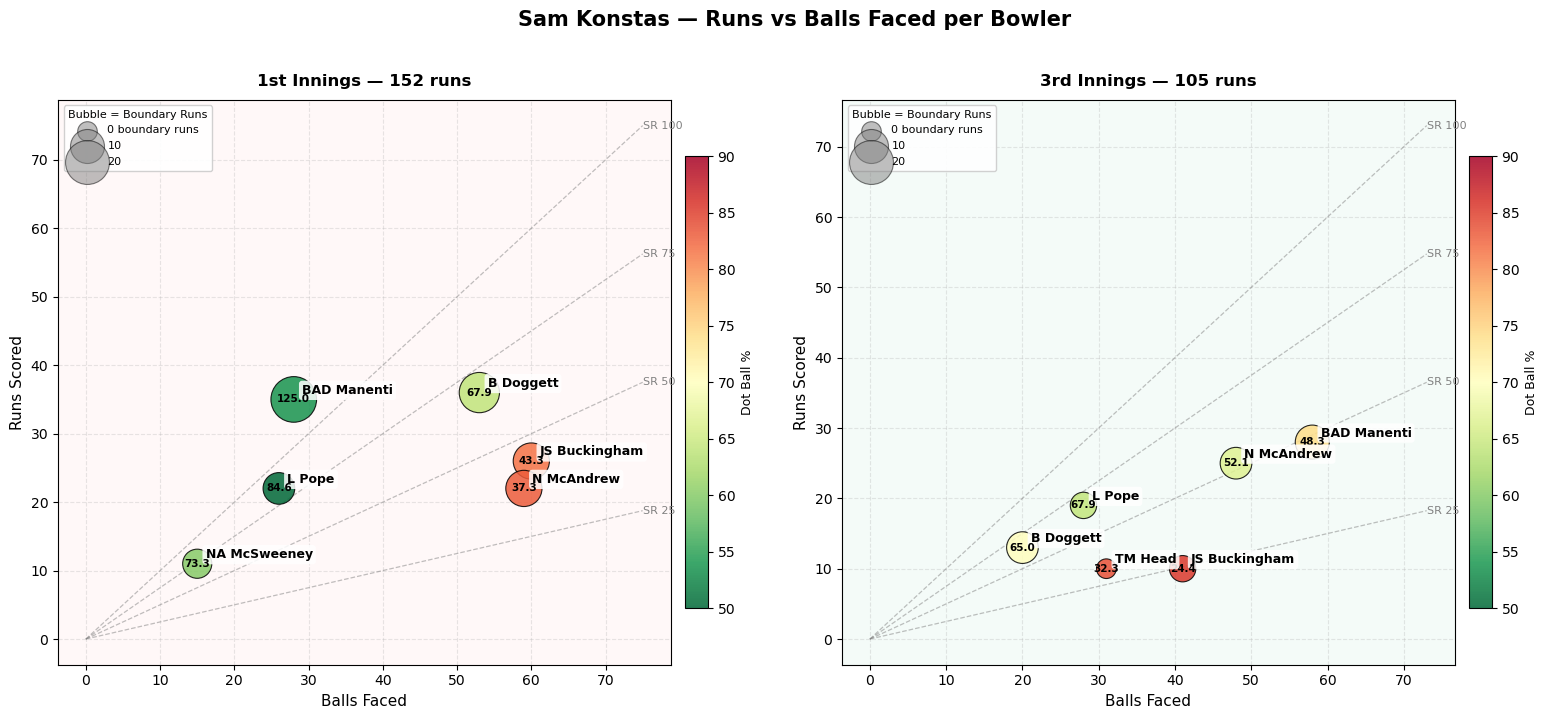

In [11]:
konstas_df = match_df[
    (match_df["batter"] == "S Konstas") &
    (match_df["innings"].isin([1, 3]))
].copy()

summary = (
    konstas_df
    .groupby(["innings", "bowler"])
    .agg(
        balls         = ("ball_in_over", "count"),
        total_runs    = ("runs_batter",  "sum"),
        boundary_runs = ("runs_batter",  lambda x: x[x >= 4].sum()),
        dot_balls     = ("runs_batter",  lambda x: (x == 0).sum()),
    )
    .reset_index()
)
summary["strike_rate"]  = (summary["total_runs"] / summary["balls"] * 100).round(1)
summary["dot_pct"]      = (summary["dot_balls"]  / summary["balls"] * 100).round(1)
summary["innings_label"] = summary["innings"].map({1: "1st Innings (152)", 3: "3rd Innings (105)"})
summary = summary[summary["balls"] >= 10]

innings_configs = [
    {"label": "1st Innings (152)", "color": "#7B0D1E", "bg": "#FFF8F8", "title": "1st Innings — 152 runs"},
    {"label": "3rd Innings (105)", "color": "#1B4332", "bg": "#F4FBF8", "title": "3rd Innings — 105 runs"},
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)
fig.suptitle("Sam Konstas — Runs vs Balls Faced per Bowler",
             fontsize=15, fontweight="bold", y=1.02)

for ax, cfg in zip(axes, innings_configs):
    subset = summary[summary["innings_label"] == cfg["label"]].reset_index(drop=True)
    ax.set_facecolor(cfg["bg"])

    sc = ax.scatter(
        subset["balls"], subset["total_runs"],
        s=(subset["boundary_runs"] + 5) * 40,
        c=subset["dot_pct"], cmap="RdYlGn_r", vmin=50, vmax=90,
        edgecolors='black', linewidths=0.8, zorder=3, alpha=0.85
    )

    # SR reference lines
    max_balls = subset["balls"].max() + 15
    for sr in [25, 50, 75, 100]:
        x_line = np.linspace(0, max_balls, 100)
        ax.plot(x_line, x_line * sr / 100, linestyle='--', linewidth=0.9, color='grey', alpha=0.5)
        ax.text(max_balls, max_balls * sr / 100, f'SR {sr}', fontsize=8, color='grey', va='center')

    # Labels
    for _, row in subset.iterrows():
        ax.annotate(row["bowler"], xy=(row["balls"], row["total_runs"]),
                    xytext=(6, 4), textcoords='offset points', fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='none', alpha=0.85))
        ax.text(row["balls"], row["total_runs"], f'{row["strike_rate"]}',
                ha='center', va='center', fontsize=7.5, fontweight='bold')

    cbar = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.8)
    cbar.set_label("Dot Ball %", fontsize=9)

    ax.set_xlabel("Balls Faced", fontsize=11)
    ax.set_ylabel("Runs Scored", fontsize=11)
    ax.set_title(cfg["title"], fontsize=12, fontweight="bold", pad=10)
    ax.grid(linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

    for bnd_runs, label in zip([0, 10, 20], ['0 boundary runs', '10', '20']):
        ax.scatter([], [], s=(bnd_runs + 5) * 40, c='grey', alpha=0.5,
                   edgecolors='black', linewidths=0.8, label=label)
    ax.legend(title="Bubble = Boundary Runs", fontsize=8, title_fontsize=8,
              loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.savefig("konstas_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

### Batter vs Bowler Profile Chart (Reusable Function)

This function generates a stacked horizontal bar showing run composition (singles, boundaries, other) against each bowler, with a dot overlay for balls faced.

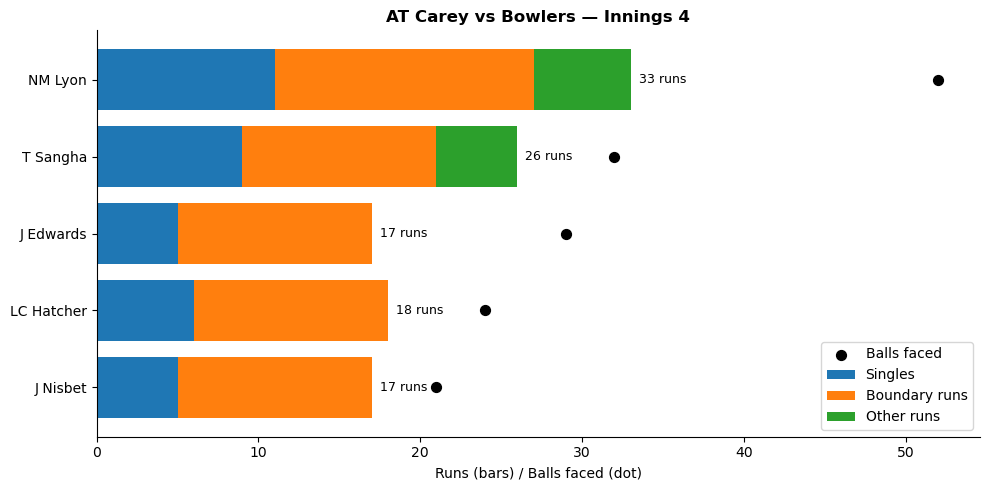

,bowler,balls,runs,singles,boundaries,boundary_runs,single_runs,other_runs
1,J Nisbet,21,17,5,3,12,5,0
2,LC Hatcher,24,18,6,3,12,6,0
0,J Edwards,29,17,5,3,12,5,0
4,T Sangha,32,26,9,3,12,9,5
3,NM Lyon,52,33,11,4,16,11,6


In [ ]:
def batter_bowler_profile_chart(df, batter_name, innings_no):
    """Stacked bar chart showing how a batter scored against each bowler in a given innings."""
    batter_df = df[(df["innings"] == innings_no) & (df["batter"] == batter_name)].copy()

    summary = (
        batter_df.groupby("bowler")
        .agg(
            balls         = ("ball_in_over", "count"),
            runs          = ("runs_batter",  "sum"),
            singles       = ("runs_batter",  lambda x: (x == 1).sum()),
            boundaries    = ("runs_batter",  lambda x: ((x == 4) | (x == 6)).sum()),
            boundary_runs = ("runs_batter",  lambda x: x[x.isin([4, 6])].sum()),
        )
        .reset_index()
    )
    summary["single_runs"] = summary["singles"]
    summary["other_runs"]  = summary["runs"] - summary["single_runs"] - summary["boundary_runs"]
    summary = summary.sort_values("balls", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(summary["bowler"], summary["single_runs"],   label="Singles")
    ax.barh(summary["bowler"], summary["boundary_runs"], left=summary["single_runs"], label="Boundary runs")
    ax.barh(summary["bowler"], summary["other_runs"],
            left=summary["single_runs"] + summary["boundary_runs"], label="Other runs")
    ax.scatter(summary["balls"], summary["bowler"], color="black", marker="o", s=50, label="Balls faced")

    for _, row in summary.iterrows():
        ax.text(row["runs"] + 0.5, row["bowler"], f'{row["runs"]} runs', va="center", fontsize=9)

    ax.set_title(f"{batter_name} vs Bowlers — Innings {innings_no}", fontweight='bold')
    ax.set_xlabel("Runs (bars) / Balls faced (dot)")
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()
    return summary

# Example usage — uncomment to generate:
# batter_bowler_profile_chart(match_df, "AT Carey", innings_no=4)
# batter_bowler_profile_chart(match_df, "NA McSweeney", innings_no=4)

## 7. Carey & McSweeney — 4th Innings Partnership Progression

Carey (111, 158 balls) and McSweeney (127*, 283 balls) put on a 182-run partnership to set up SA's chase. The chart below shows their individual cumulative run progressions with:
- Phase shading (overs 1–20, 21–50, 51+)
- Milestone markers at 50 and 100
- Wicket markers for all 4th innings dismissals

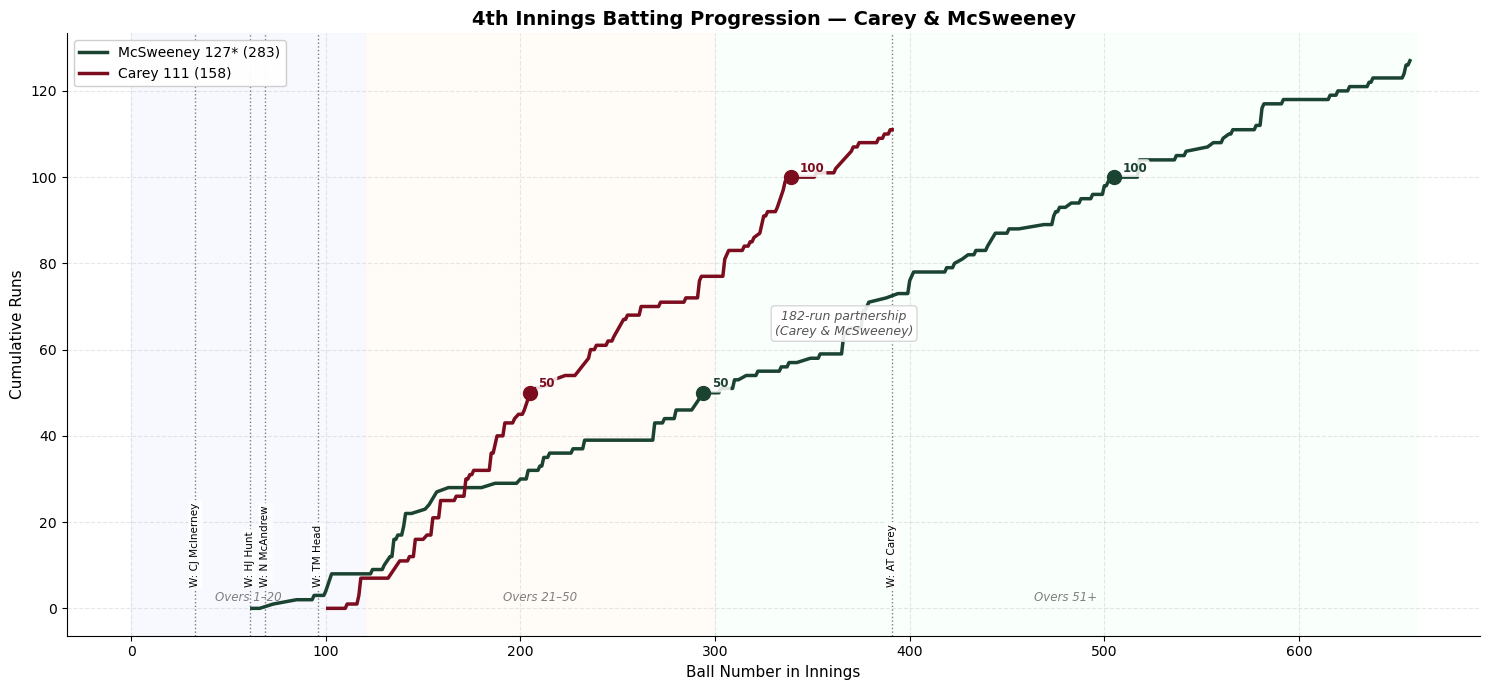

In [13]:
fourth_df = match_df[match_df["innings"] == 4].copy()
fourth_df["ball_number"] = fourth_df["over"] * 6 + fourth_df["ball_in_over"]
fourth_df = fourth_df.sort_values("ball_number")
wickets_df = fourth_df[fourth_df["is_wicket"] == 1].copy()

batter_configs = [
    {"name": "NA McSweeney", "color": "#1B4332", "label": "McSweeney 127* (283)"},
    {"name": "AT Carey",     "color": "#7B0D1E", "label": "Carey 111 (158)"},
]

phase_bands = [
    {"label": "Overs 1–20",  "start": 0,   "end": 120,  "color": "#f0f4ff"},
    {"label": "Overs 21–50", "start": 120, "end": 300,  "color": "#fff8f0"},
    {"label": "Overs 51+",   "start": 300, "end": 9999, "color": "#f4fff8"},
]

fig, ax = plt.subplots(figsize=(15, 7))
max_ball = fourth_df["ball_number"].max()

# Phase shading
for phase in phase_bands:
    end = min(phase["end"], max_ball)
    if phase["start"] > max_ball: continue
    ax.axvspan(phase["start"], end, color=phase["color"], alpha=0.5, zorder=0)
    ax.text((phase["start"] + end) / 2, 1, phase["label"],
            ha='center', va='bottom', fontsize=8.5, color='grey', style='italic')

# Batter progression lines
for cfg in batter_configs:
    batter_balls = fourth_df[fourth_df["batter"] == cfg["name"]].sort_values("ball_number").copy()
    batter_balls["cumulative_runs"] = batter_balls["runs_batter"].cumsum()
    ax.plot(batter_balls["ball_number"], batter_balls["cumulative_runs"],
            color=cfg["color"], linewidth=2.5, label=cfg["label"], zorder=3)

    # Milestone markers
    for milestone in [50, 100]:
        reached = batter_balls[batter_balls["cumulative_runs"] >= milestone]
        if not reached.empty:
            row = reached.iloc[0]
            ax.scatter(row["ball_number"], milestone, color=cfg["color"], s=100, zorder=5)
            ax.annotate(str(milestone), xy=(row["ball_number"], milestone),
                        xytext=(6, 4), textcoords='offset points',
                        fontsize=8.5, fontweight='bold', color=cfg["color"],
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.85))

# Wicket markers
for _, row in wickets_df.iterrows():
    ax.axvline(row["ball_number"], color='black', linewidth=1, linestyle=':', alpha=0.5, zorder=2)
    ax.text(row["ball_number"], 5, f'W: {row["player_dismissed"]}',
            ha='center', va='bottom', fontsize=7.5, color='black', rotation=90,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.85))

# Partnership annotation
ax.annotate('182-run partnership\n(Carey & McSweeney)',
            xy=(0.55, 0.5), xycoords='axes fraction',
            fontsize=9, style='italic', color='#555555', ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgrey', alpha=0.9))

ax.set_title("4th Innings Batting Progression — Carey & McSweeney",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Ball Number in Innings", fontsize=11)
ax.set_ylabel("Cumulative Runs", fontsize=11)
ax.grid(linestyle='--', alpha=0.3, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=10, loc='upper left', framealpha=0.95)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("carey_mcsweeney_progression.png", dpi=150, bbox_inches='tight')
plt.show()